# Module 5 — LoRA-Adapted RoBERTa Evidence Audit

**Question:** Can parameter-efficient adaptation of a pinned RoBERTa-base model outperform the leakage-safe TF-IDF and frozen-embedding baselines on fine-grained banking-intent routing?

**Registered decision:** select two LoRA candidates using validation macro-F1 only, lock the winning SafeTensors checkpoint, then evaluate once on the official test split. This notebook reads the generated, text-free evidence; it does not retrain or expose customer messages.

**Observed answer:** No for this registered three-epoch protocol. The selected rank-8 adapter reached 0.8202 test macro-F1, versus 0.9053 for TF-IDF and 0.8964 for frozen RoBERTa. Both LoRA validation curves were still rising, so the supported diagnosis is undertraining—not a general claim that LoRA is inferior.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook inside the project checkout.")


ROOT = find_project_root(Path.cwd())
selection = json.loads((ROOT / "reports/lora-roberta/selection.json").read_text())
evaluation = json.loads((ROOT / "reports/lora-roberta/test.json").read_text())
comparisons = json.loads((ROOT / "reports/lora-roberta/paired-comparisons.json").read_text())
{
    "project_root": str(ROOT),
    "device": selection["runtime_device"]["selected"],
    "selected_candidate": selection["selected_candidate"],
    "selection_lock": selection["selection_sha256"][:12],
    "test_lock": evaluation["evaluation_sha256"][:12],
}

{'project_root': '/Users/coded/Downloads/IAPP-Artificial-Intelligence-Governance-Professional-AIGP-Complete-Course/AI Engineer/governed-banking-intent-router',
 'device': 'mps',
 'selected_candidate': 'lora_r8_lr2e4',
 'selection_lock': '101caa04f926',
 'test_lock': '1b8c569dbc90'}

## Architecture and candidate contract

The base Transformer remains frozen. LoRA injects trainable low-rank matrices into every attention `query` and `value` projection. PEFT also trains and saves the newly initialised 77-class classification head. The candidates differ in rank, scaling and learning rate; all other training controls are fixed.

In [2]:
candidate_rows = []
for result in selection["candidate_results"]:
    candidate = result["candidate"]
    params = result["parameters"]
    candidate_rows.append(
        {
            "candidate": result["candidate_name"],
            "rank": candidate["rank"],
            "alpha": candidate["alpha"],
            "learning_rate": candidate["learning_rate"],
            "trainable_parameters": params["trainable_parameters"],
            "trainable_%": params["trainable_percentage"],
            "best_epoch": result["best_epoch"],
            "validation_macro_f1": result["best_validation_metrics"]["macro_f1"],
            "adapter_MiB": result["checkpoint"]["total_bytes"] / 2**20,
        }
    )
pd.DataFrame(candidate_rows).sort_values("validation_macro_f1", ascending=False).round(4)

,candidate,rank,alpha,learning_rate,trainable_parameters,trainable_%,best_epoch,validation_macro_f1,adapter_MiB
0,lora_r8_lr2e4,8,16,0.0002,944717,0.7519,3,0.8241,3.6174
1,lora_r16_lr1e4,16,32,0.0001,1239629,0.9843,3,0.6774,4.7425


## Validation learning curves

A winner at the final registered epoch can still indicate an inadequate search boundary. We inspect the pre-test validation trajectory before interpreting the locked result.

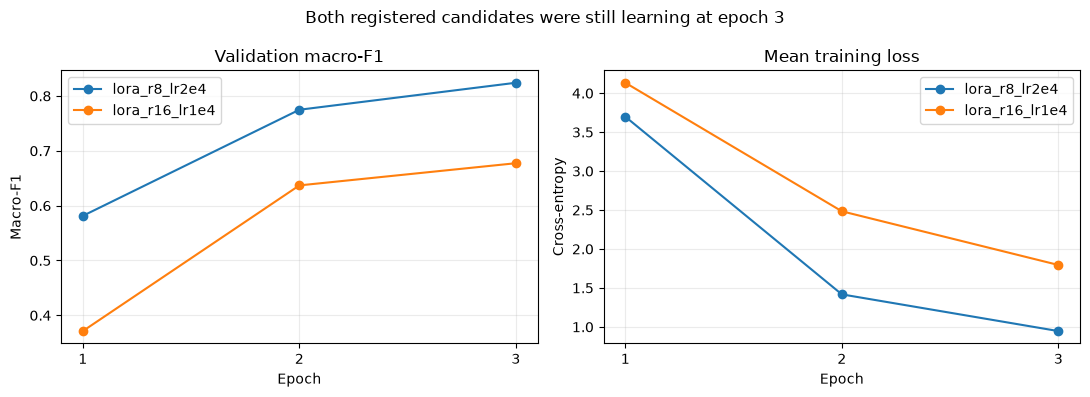

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for result in selection["candidate_results"]:
    epochs = [row["epoch"] for row in result["epochs"]]
    macro_f1 = [row["validation"]["macro_f1"] for row in result["epochs"]]
    loss = [row["mean_training_loss"] for row in result["epochs"]]
    axes[0].plot(epochs, macro_f1, marker="o", label=result["candidate_name"])
    axes[1].plot(epochs, loss, marker="o", label=result["candidate_name"])
axes[0].set(title="Validation macro-F1", xlabel="Epoch", ylabel="Macro-F1", xticks=[1, 2, 3])
axes[1].set(title="Mean training loss", xlabel="Epoch", ylabel="Cross-entropy", xticks=[1, 2, 3])
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle("Both registered candidates were still learning at epoch 3")
fig.tight_layout()

## Locked comparison

The table below uses the same 3,080 official test rows. Lower log-loss is better; all other displayed metrics are higher-is-better. Confidence remains uncalibrated.

In [4]:
baseline_reports = {
    "TF-IDF": json.loads((ROOT / "reports/baseline/tfidf-logreg-test.json").read_text()),
    "Frozen RoBERTa": json.loads((ROOT / "reports/frozen-roberta/test.json").read_text()),
    "LoRA RoBERTa": evaluation,
}
metric_names = ["accuracy", "macro_f1", "weighted_f1", "log_loss", "top_3_accuracy"]
locked_table = pd.DataFrame(
    {
        name: {metric: report["test_result"]["metrics"][metric] for metric in metric_names}
        for name, report in baseline_reports.items()
    }
)
locked_table.round(4)

,TF-IDF,Frozen RoBERTa,LoRA RoBERTa
accuracy,0.9052,0.8961,0.8273
macro_f1,0.9053,0.8964,0.8202
weighted_f1,0.9053,0.8964,0.8202
log_loss,0.4970,0.3990,0.7746
top_3_accuracy,0.9705,0.9718,0.9497


In [5]:
paired_rows = []
for comparison in comparisons["comparisons"]:
    correctness = comparison["correctness"]
    metrics = comparison["metrics"]
    paired_rows.append(
        {
            "reference": comparison["reference_model"],
            "LoRA minus reference macro-F1": metrics["candidate_minus_reference_macro_f1"],
            "reference only correct": correctness["reference_only_correct"],
            "LoRA only correct": correctness["candidate_only_correct"],
            "discordant rows": correctness["discordant_rows"],
            "exact p-value": metrics["exact_mcnemar_two_sided_p_value"],
        }
    )
pd.DataFrame(paired_rows).round(4)

,reference,LoRA minus reference macro-F1,reference only correct,LoRA only correct,discordant rows,exact p-value
0,tfidf_logistic_regression,-0.0851,350,110,460,0.0
1,frozen_roberta_mean_logistic_regression,-0.0762,345,133,478,0.0


## Material failure slices

,f1,precision,recall,support
contactless_not_working,0.2609,1.0000,0.150,40
virtual_card_not_working,0.3673,1.0000,0.225,40
topping_up_by_card,0.5079,0.6957,0.400,40
card_acceptance,0.6557,0.9524,0.500,40
card_swallowed,0.6667,1.0000,0.500,40
transfer_timing,0.6667,0.6585,0.675,40
declined_card_payment,0.6729,0.5373,0.900,40
supported_cards_and_currencies,0.6842,0.7222,0.650,40
why_verify_identity,0.7077,0.9200,0.575,40
balance_not_updated_after_bank_transfer,0.7111,0.6400,0.800,40


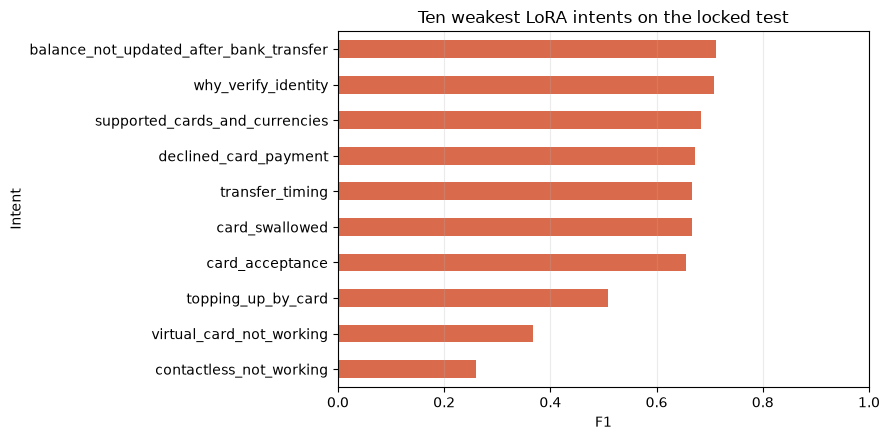

In [6]:
per_intent = evaluation["test_result"]["metrics"]["per_intent"]
weakest = pd.DataFrame.from_dict(per_intent, orient="index").sort_values(["f1", "recall"]).head(10)
ax = weakest["f1"].sort_values().plot.barh(figsize=(9, 4.5), color="#d96b4c")
ax.set(title="Ten weakest LoRA intents on the locked test", xlabel="F1", ylabel="Intent")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
weakest.round(4)

## Evidence and privacy assertions

In [7]:
from governed_banking.baseline import assert_text_free_artifact
from governed_banking.data import stable_json_sha256


def verify_content_hash(artifact: dict, field: str) -> bool:
    body = dict(artifact)
    expected = body.pop(field)
    return expected == stable_json_sha256(body)


assert_text_free_artifact(selection)
assert_text_free_artifact(evaluation)
assert selection["data_boundary"]["test_split_loaded"] is False
assert evaluation["data_boundary"]["selection_was_locked_before_test"] is True
assert evaluation["selection_sha256"] == selection["selection_sha256"]
assert verify_content_hash(selection, "selection_sha256")
assert verify_content_hash(evaluation, "evaluation_sha256")
{
    "reports_are_text_free": True,
    "selection_preceded_test": True,
    "content_hashes_valid": True,
    "test_rows": evaluation["data_boundary"]["test_rows"],
}

{'reports_are_text_free': True,
 'selection_preceded_test': True,
 'content_hashes_valid': True,
 'test_rows': 3080}

## Decision

Preserve Module 5 as a negative, reproducible baseline. Do not extend training and promote a new score on the already observed test set as confirmatory evidence. The next development protocol should use validation-only stopping, multiple seeds, and a genuinely independent confirmation set before claiming improvement. Calibration, uncertainty and routing policy work must also continue to treat every confidence value here as uncalibrated.